In [1]:
# auto reload modified modules
%load_ext autoreload
%autoreload 2
import os
import sys
from pathlib import Path
def _find_repo_root(start):
    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir() and (candidate / "experiments").is_dir():
            return candidate
    return start
CODE_DIR = os.environ.get("ETA_CODE_DIR")
if CODE_DIR is None:
    CODE_DIR = str(_find_repo_root(Path.cwd()))
WORK_DIR = os.environ.get("ETA_WORK_DIR", CODE_DIR)
SRC_DIR = str(Path(CODE_DIR) / "src")
for import_path in (CODE_DIR, SRC_DIR):
    if import_path not in sys.path:
        sys.path.insert(0, import_path)

import numpy as np
import torch 
import torch.nn as nn
from torch.nn import functional as F 
from utils import *
from plot_utils import *
from copy import deepcopy
from tqdm import tqdm
import matplotlib.pyplot as plt 
import gc
plot_setting()
seed = 1

### Import Data

In [2]:
n_train = 100
var_in = 10
data_path = WORK_DIR + '/data/toy.pth'
DATA = torch.load(data_path)

X = DATA['X_all']
Y = DATA['Y_all']
GRIDS = DATA['in_grid']
Y_GRID = DATA['out_grid']
x_train = DATA['x_train']
y_train = DATA['y_train']
x_train_e = DATA['x_train_e']
y_train_e = DATA['y_train_e']

N = int(np.sqrt(GRIDS.shape[0]))
X1 = GRIDS[:,0].reshape((N,N))
X2 = GRIDS[:,1].reshape((N,N))
Y_GRID = Y_GRID.reshape((N,N))
n_train = x_train.shape[0]

In [3]:
# define input distribution 
d = 2
mu_in = torch.zeros(d)
cov_in = torch.eye(d) * var_in
option_in = 'mvn'
input_sampler = input(mu_in, cov_in, option_in)

### Output PDF

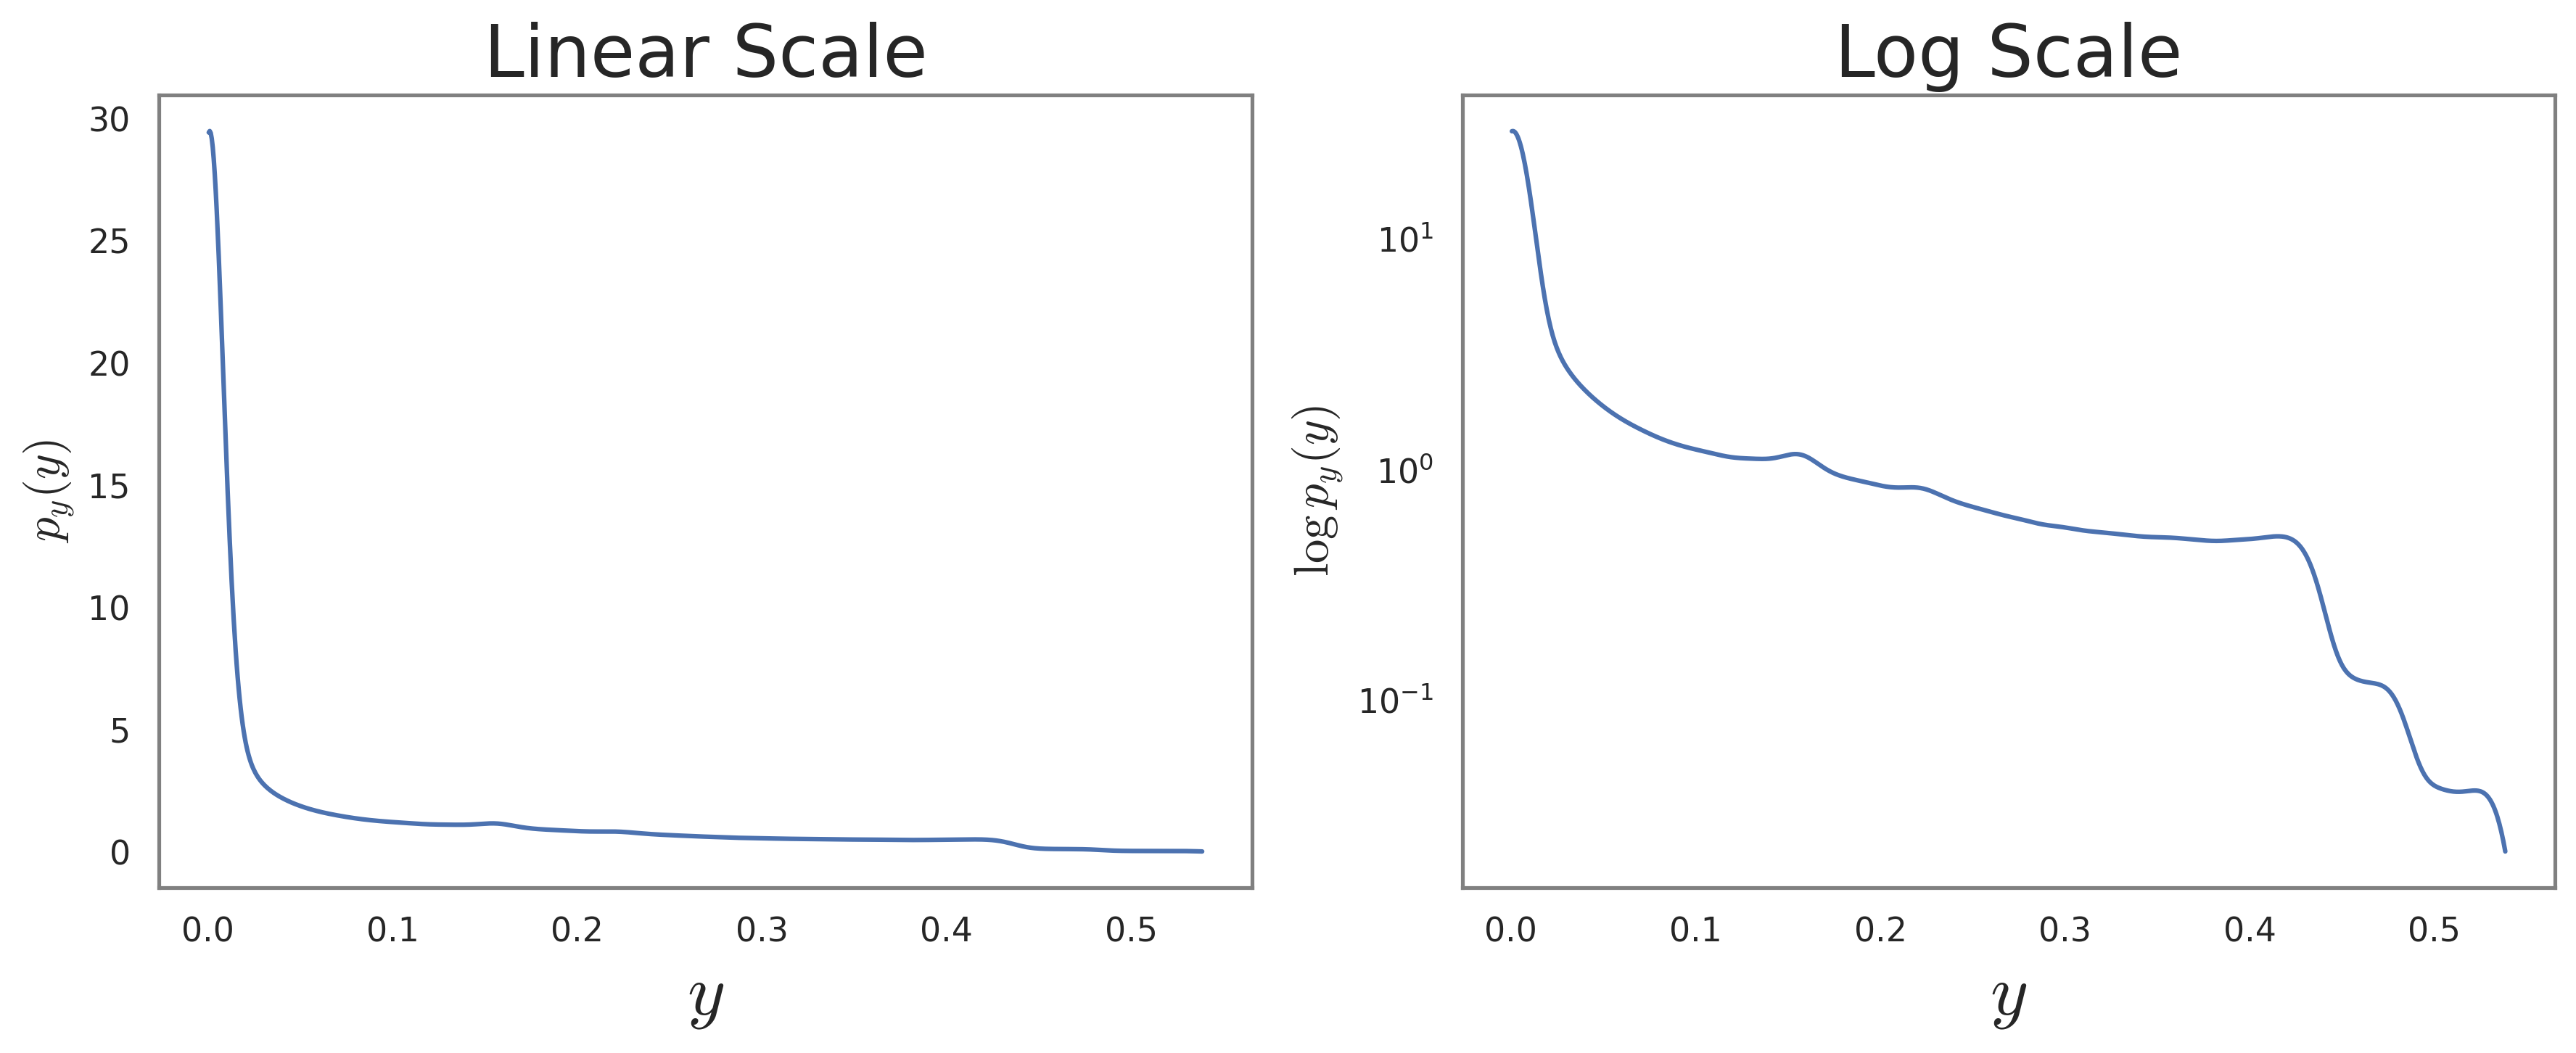

In [4]:
from kde import get_data_pdf

# get input pdf vals
pX = input_sampler.pdf(X)

# output pdf
y_true, py_true, y_true_pdf = get_data_pdf(Y, Y, None)

title_true_pdf = None
fig_true_pdf, ax_true_pdf = plot_pdf(y_true, py_true, title=title_true_pdf)
ax_true_pdf[0].set_ylabel(r"$p_y(y)$", fontsize=16)
ax_true_pdf[1].set_ylabel(r"$\log{p_y(y)}$", fontsize=16)
fig_true_pdf.tight_layout()

# fig_true_pdf.savefig('./figs/true-output-pdf1.png')

### Import NN and Training and Testing Wrappers


In [5]:
from train_utils import train_nn
from test_utils import *
from models import FCNN

### MSE-Loss NN (This takes 20 seconds on NVIDIA V100)

In [6]:
global_seed(1)
dimensions = [
    256,256,256
]
activation = 'psilu'
indim = 2
outdim = 1
init = 'xavier normal'
loss_fun = nn.MSELoss
optim = torch.optim.Adam
epochs = 3000
batch_size = n_train
opt_params = {
    'lr' : 1e-4
}

# train on selected dataset
msenn = FCNN(dimensions, activation=activation, indim=indim, outdim=outdim, init=init)
msenn = nn.DataParallel(msenn)
mse_res = train_nn(msenn, x_train, y_train, loss_fun,
                   optim, epochs, batch_size, device("all"), **opt_params)

# evaluate on 100x100 grid
mse_eval_res = eval_result(mse_res, GRIDS, X)

# release memory
msenn = None
gc.collect()
torch.cuda.empty_cache()

100%|██████████| 3000/3000 [00:35<00:00, 85.10it/s] 


3000


Text(0.5, 1.0, 'MSE-NN Loss')

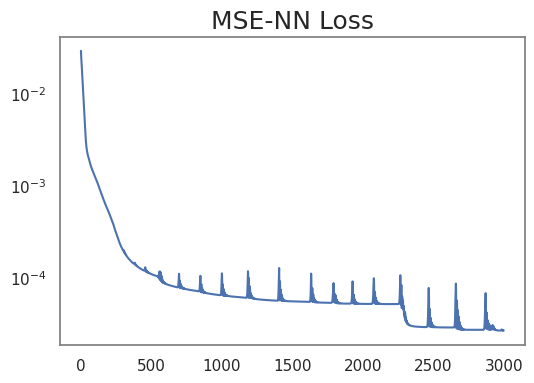

In [7]:
plt.figure(figsize=(6,4))
plt.semilogy(mse_res.loss)
print(len(mse_res.loss))
plt.title("MSE-NN Loss", fontsize=18)
# plt.savefig(f"./figs/fcnn-loss-mse-N{n_train}.png")

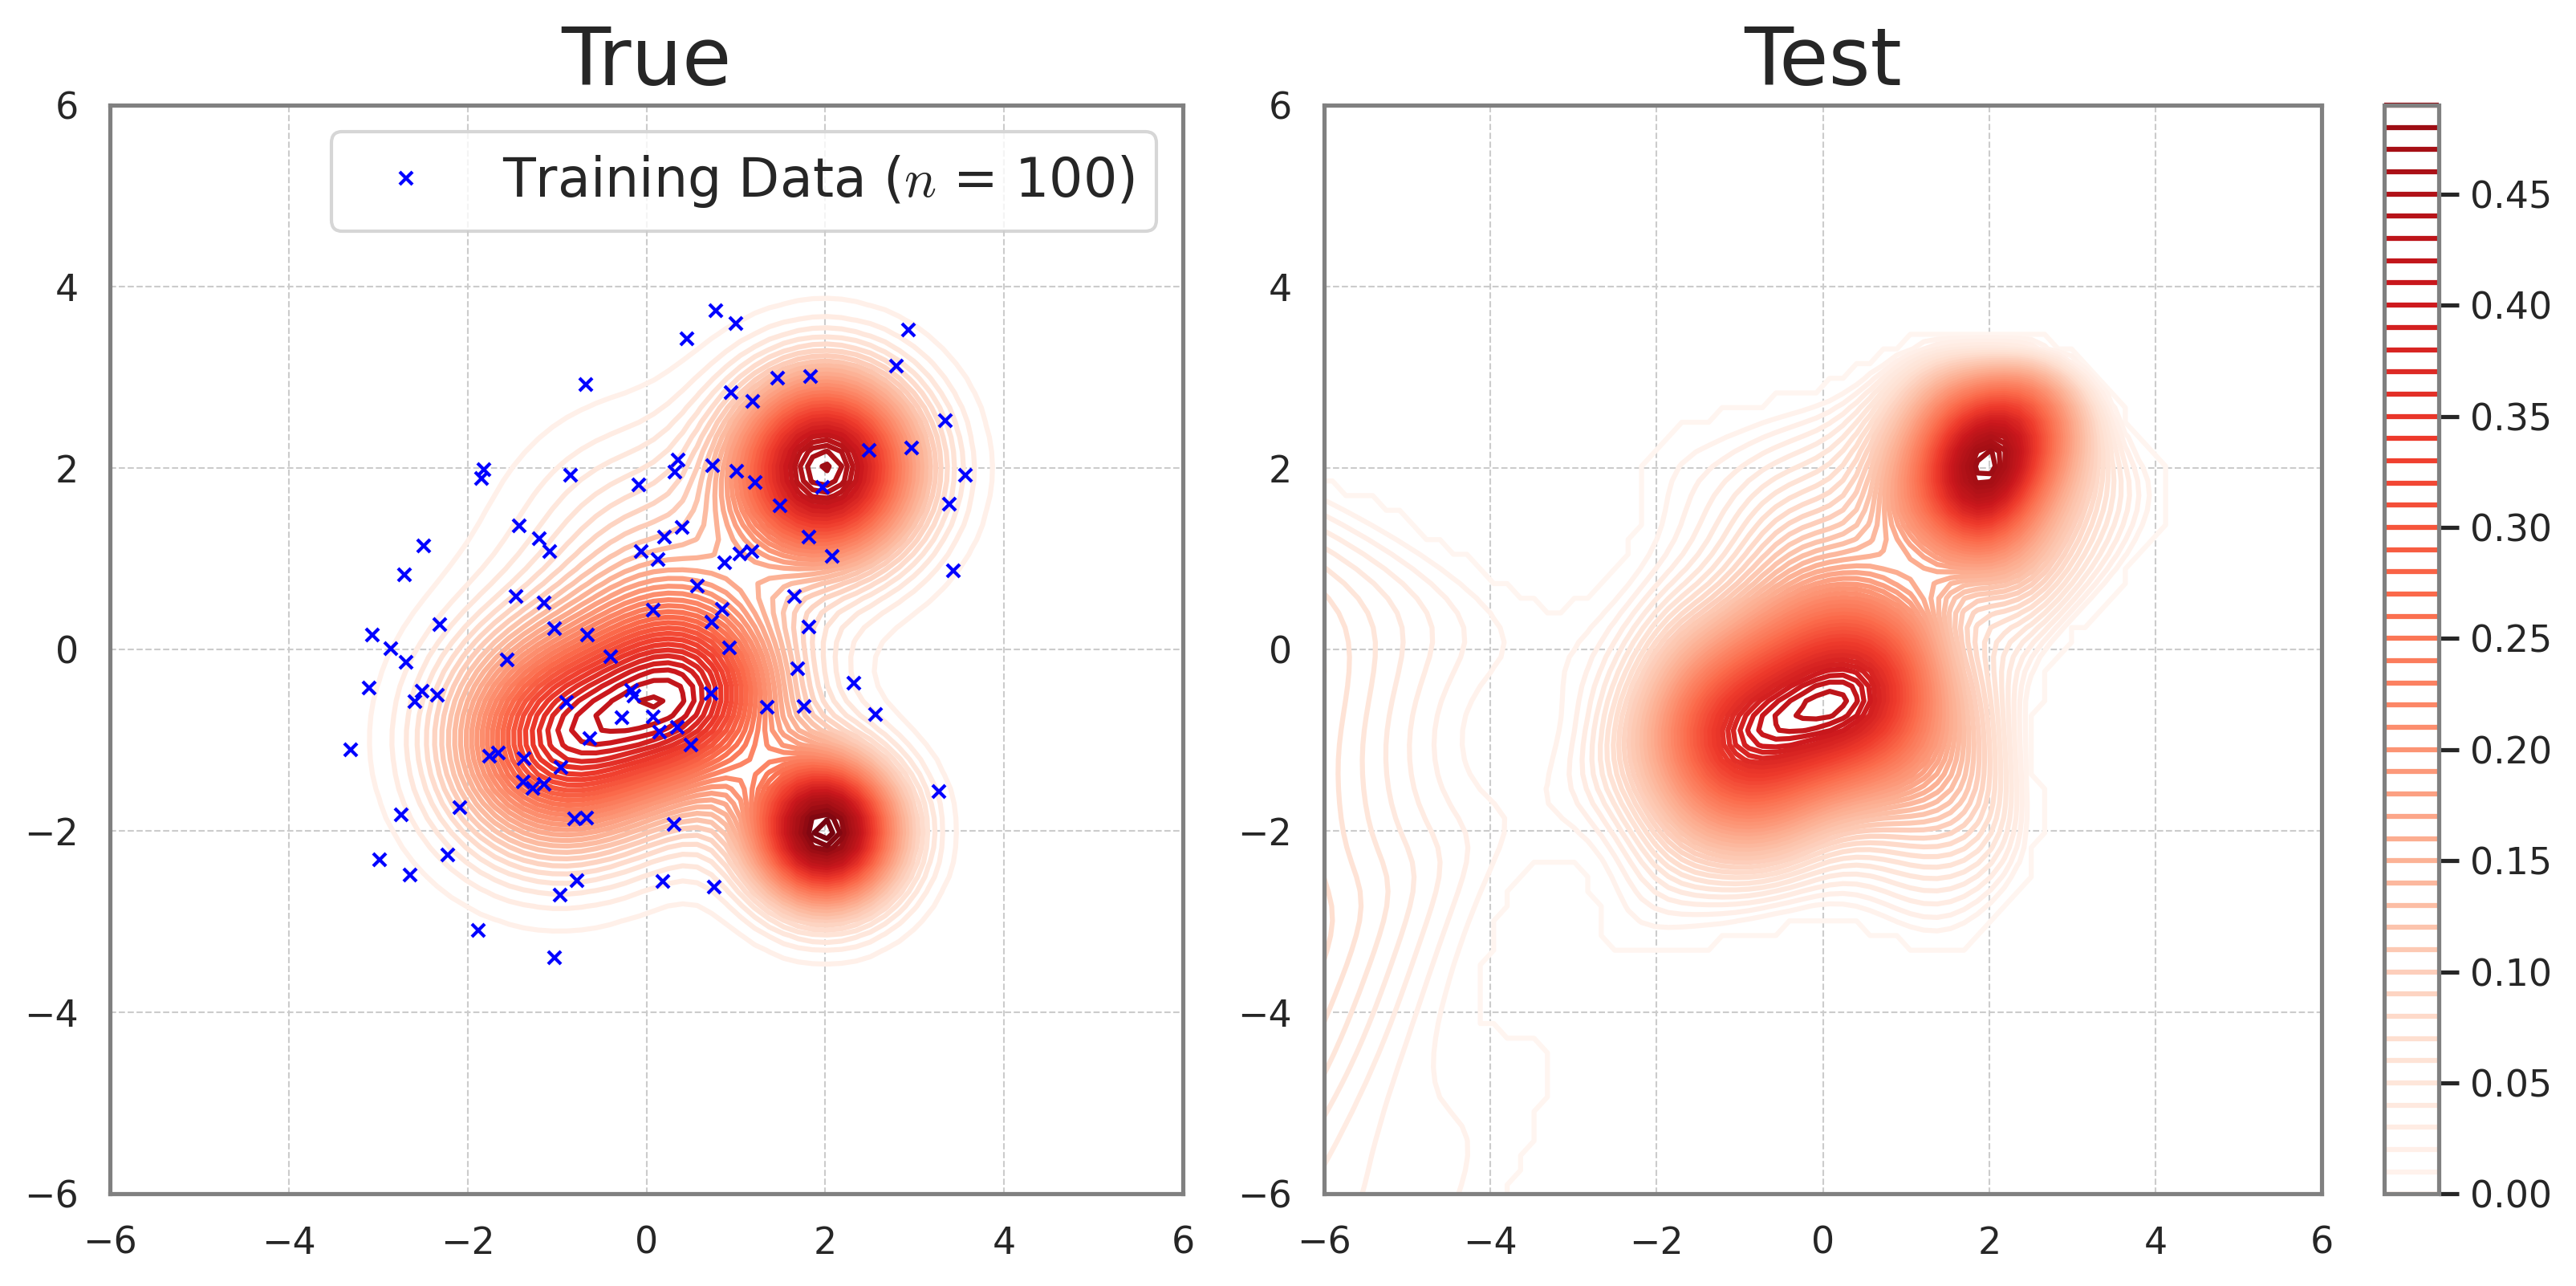

In [8]:
# plot test result

fig_mse_pred, ax_mse_pred = plot_2contours(X1, X2, Y_GRID, mse_eval_res.y_grid, x_scatter=x_train)
fig_mse_pred, ax_mse_pred = add_true_vs_e2a_title(fig_mse_pred, ax_mse_pred)
# fig_mse_pred.suptitle("MSE-NN Prediction", fontsize=30)

# fig_mse_pred.savefig(f'./figs/fcnn-pred-mse-N{n_train}.png')

(0.01, 50)

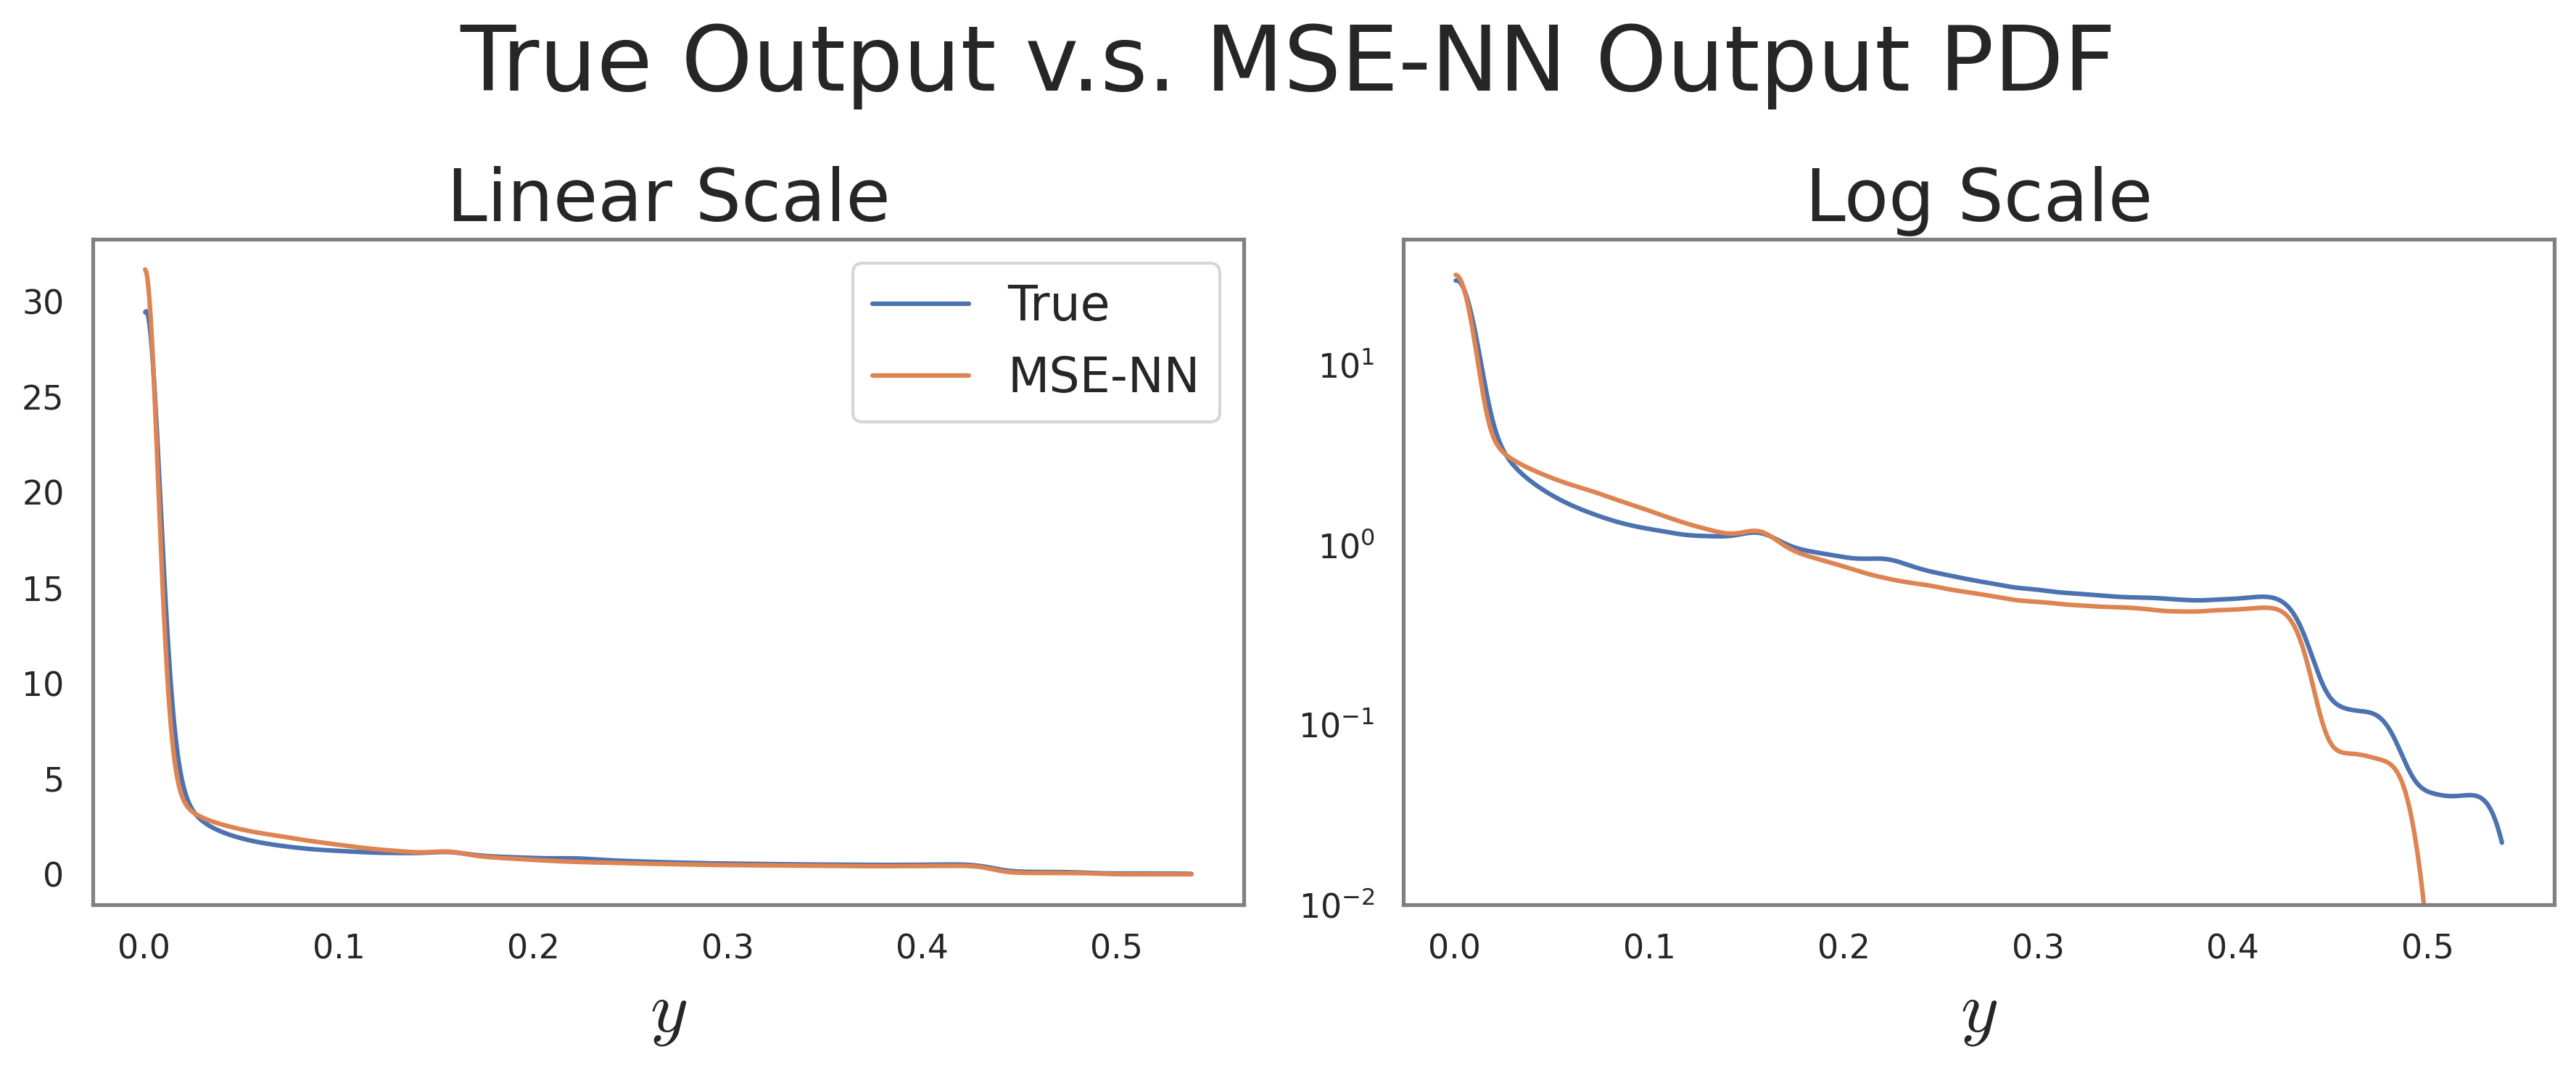

In [9]:
# estimate e2a output pdf with KDE
y_mse, py_mse, y_mse_pdf = get_data_pdf(mse_eval_res.y_samples, Y, None)

# plot
title_mse_pdf = "True Output v.s. MSE-NN Output PDF"
fig_mse_pdf, ax_mse_pdf = plot_pdf(y_true, py_true, label="True", title=title_mse_pdf)
fig_mse_pdf, ax_mse_pdf = plot_pdf(y_mse, py_mse, label="MSE-NN", fig=fig_mse_pdf, ax=ax_mse_pdf)
fig_mse_pdf.tight_layout()
ax_mse_pdf[1].set_ylim(1e-2, 50)

# plt.savefig(f"./figs/fcnn-pdf-mse-N{n_train}.png")

In [10]:
from train_utils import train_eta_xy, grf_pretrain, generate_2d_gaussian

In [11]:
# define quantiles
quantiles = torch.cat((
    torch.linspace(0.0,0.0001,10), torch.linspace(0.0001,0.001,10), torch.linspace(0.001,0.01,10), 
    torch.linspace(0.01,0.1,9), torch.linspace(0.1,0.9,20), torch.linspace(0.9,0.99,21), torch.linspace(0.99,0.999,21), 
    torch.linspace(0.999,0.9999,21), torch.linspace(0.9999,0.99999,21), torch.linspace(0.99999,0.999999,21), torch.linspace(0.999999,0.9999999,21)
))

# Multiple Runs of ETA Learning

In [ ]:
from models import FCNN

eta_res_list = []
eta_eval_res_list = []
seed_list = [22,25,27,28,29,32,33,51,54,57,58,63,64,67]
seed_list = [25]
# seed_list = [22,25,27,28,29,32,33,38,39,40,41,43,51,54,57,58,63,64,67]

# set device
_device = device("all")

# quantile loss
quantiles = quantiles
pretrain_epochs = 1000
epochs = 4000
batch_size = n_train
_lamb = 1.
omega = 10

# network parameters
n_neurons = 256
dimensions = [
    n_neurons,n_neurons,n_neurons
]
activation = 'psilu'
indim = 2
outdim = 1
init = 'xavier normal'
loss_fun = nn.MSELoss
optim = torch.optim.Adam

# seed = 50
# for k in range(20):
    # seed += 1
for seed in seed_list:
    global_seed(seed)
    print('seed : ', seed)

    # pretraining
    etann_pretrain = FCNN(dimensions, activation, indim, outdim, init, False).to(_device)
    etann_pretrain = nn.DataParallel(etann_pretrain)
    n_grid = 50
    grid_step = 100 // n_grid
    gaussian_field, center = generate_2d_gaussian(seed=seed, sigma=0.3)
    pretrain_res = grf_pretrain(gaussian_field, etann_pretrain, pretrain_epochs, n_grid=n_grid, grid_step=grid_step, device=_device)

    # continual training
    etann = pretrain_res.model
    eta_res = train_eta_xy(etann, x_train, y_train, X, Y, quantiles,
                           optim, epochs, batch_size, _device, _lamb, omega)
    eta_eval_res = eval_result(eta_res, GRIDS, X, best_model=True)

    eta_res_list.append(eta_res)
    eta_eval_res_list.append(eta_eval_res)
    
    # fig, ax = plt.subplots(1,2,figsize=(12,4))
    # ax[0].contour(X1.numpy(), X2.numpy(), eta_eval_res.y_grid.cpu().numpy(), levels=36, cmap='Reds')
    # ax[0].set_xlim(-6,6)
    # ax[0].set_ylim(-6,6)
    # ax[0].set_xlabel(r'$x_1$')
    # ax[0].set_ylabel(r'$x_2$')

    # y_eta, py_eta, y_eta_pdf = get_data_pdf(eta_eval_res.y_samples, Y, None)
    # ax[1].plot(y_true, py_true, linewidth=2, label='Truth')
    # ax[1].plot(y_mse, py_mse, '-.', linewidth=2, label='MSE')
    # ax[1].plot(y_eta, py_eta, '--', linewidth=2, label=r'$\eta$')
    # ax[1].set_yscale('log')
    # ax[1].set_xlabel(r'$y$')
    # ax[1].set_ylabel(r'$\log p(y)$')
    # ax[1].set_ylim(1e-2, 50)
    # ax[1].legend(prop={'size': 16})

    # fig.tight_layout()
    # plt.show()
    # plt.close()


seed :  25


  6%|▌         | 56/1000 [00:00<00:06, 141.67it/s]

100%|██████████| 3000/3000 [01:49<00:00, 27.40it/s]


seed:  25


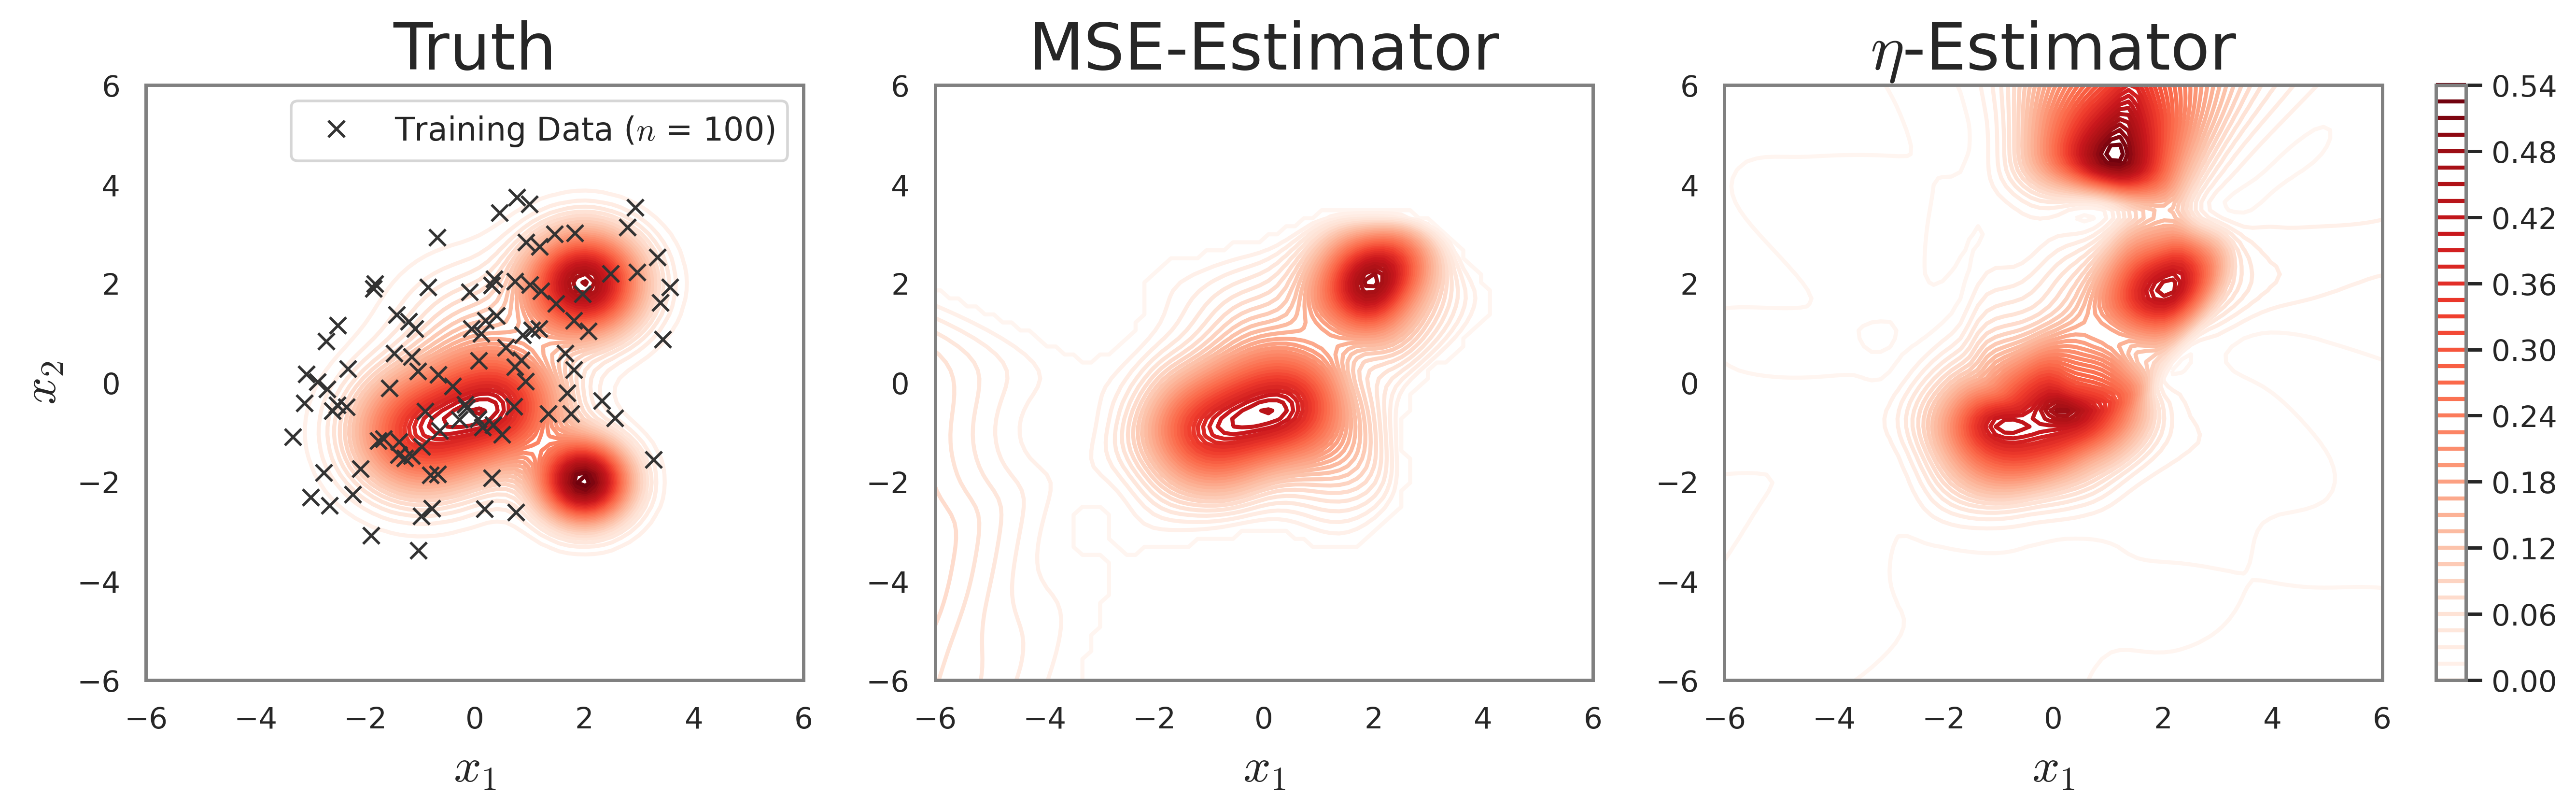

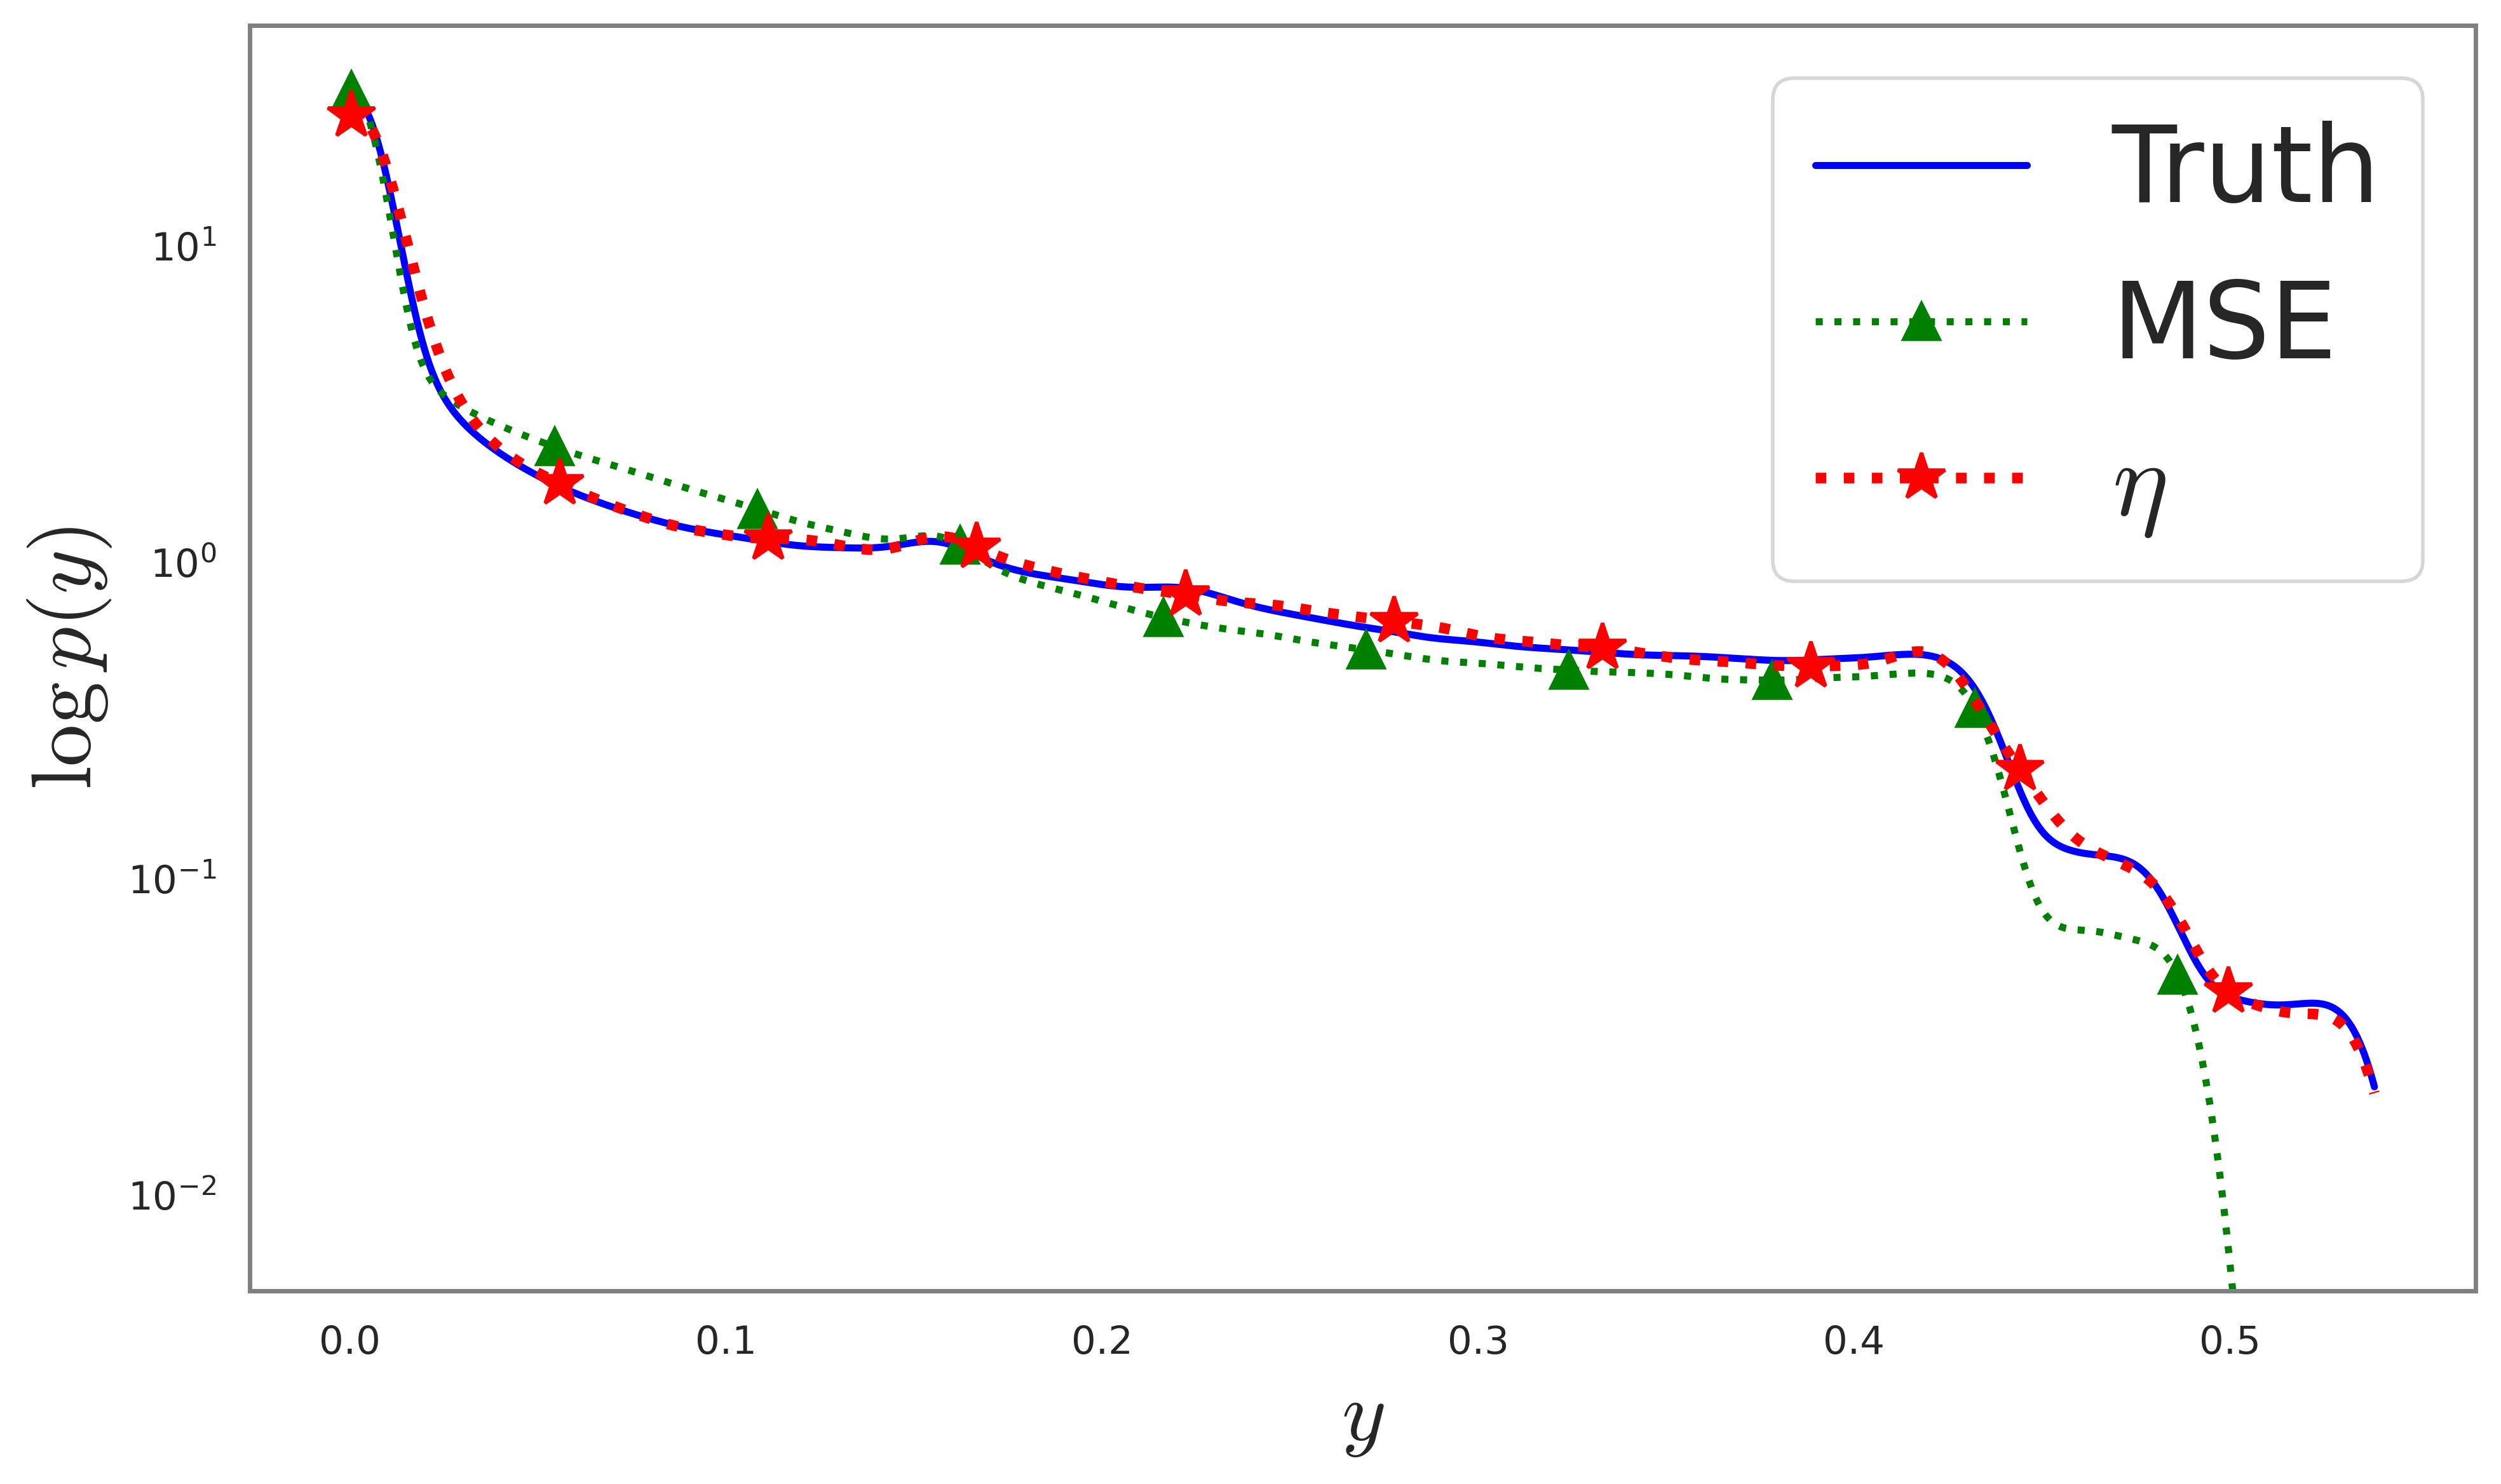

In [21]:
for i,seed in enumerate(seed_list):
    print('seed: ', seed_list[i])
    eta_eval_res = eta_eval_res_list[i]
    fig1, ax1 = plt.subplots(1,3,figsize=(18,4), dpi=400) 
    # Find global min and max for consistent color scale
    vmin = 0#min(torch.min(U1_GRID).item(), np.min(mse_eval_res.u1_grid).item())
    vmax = max(torch.max(Y_GRID).item(), torch.max(mse_eval_res.y_grid).item(), torch.max(eta_eval_res.y_grid).item())
    # Create contour plots with same levels and color scale
    contour_truth = ax1[0].contour(X1,X2,Y_GRID.cpu().numpy(), levels=36, cmap='Reds', vmin=vmin, vmax=vmax)
    ax1[0].set_title(r"Truth", fontsize=24)
    ax1[0].set_xlabel(r"$x_1$", fontsize=18)
    ax1[0].set_ylabel(r"$x_2$", fontsize=18)
    ax1[0].plot(x_train[:,0], x_train[:,1], 'x', markersize=6, color='#333333', alpha=1, linewidth=2,
                    label=r'Training Data ($n$' + f' = {n_train})')
    ax1[0].set_xlim(-6,6)
    ax1[0].set_ylim(-6,6)
    ax1[0].legend(prop={'size':12})
    contour2 = ax1[1].contour(X1,X2,mse_eval_res.y_grid.cpu().numpy(), levels=36, cmap='Reds', vmin=vmin, vmax=vmax)
    ax1[1].set_title(r"MSE-Estimator", fontsize=24)
    ax1[1].set_xlabel(r"$x_1$", fontsize=18)
    ax1[1].set_xlim(-6,6)
    ax1[1].set_ylim(-6,6)
    contour3 = ax1[2].contour(X1,X2,eta_eval_res.y_grid.cpu().numpy(), levels=36, cmap='Reds', vmin=vmin, vmax=vmax)
    ax1[2].set_title(r"$\eta$-Estimator", fontsize=24)
    ax1[2].set_xlabel(r"$x_1$", fontsize=18)
    ax1[2].set_xlim(-6,6)
    ax1[2].set_ylim(-6,6)
    # Add a colorbar that applies to all plots
    fig1.colorbar(contour_truth, ax=ax1, shrink=1, pad=0.02)

    y_eta, py_eta, y_eta_pdf = get_data_pdf(eta_eval_res.y_samples, Y, None)
    fig3 = plt.figure(figsize=(10,6), dpi=400)
    plt.plot(y_true, py_true, label=r"Truth", color='blue', linestyle='-', linewidth=2)
    plt.plot(y_mse, py_mse, label=r"MSE", color='green', linestyle=':', 
            marker='^', markevery=100, linewidth=2, markersize=10)
    plt.plot(y_eta, py_eta, label=r"$\eta$", color='red', linestyle=':', 
            marker='*', markersize=14, markevery=100, linewidth=3)
    plt.xlabel(r"$y$", fontsize=24)
    plt.ylabel(r"$\log{p(y)}$", fontsize=24)
    plt.yscale('log')
    plt.ylim(5e-3, 50)
    plt.legend(prop={'size': 30})
    plt.tight_layout()
    plt.show()

#     assert False

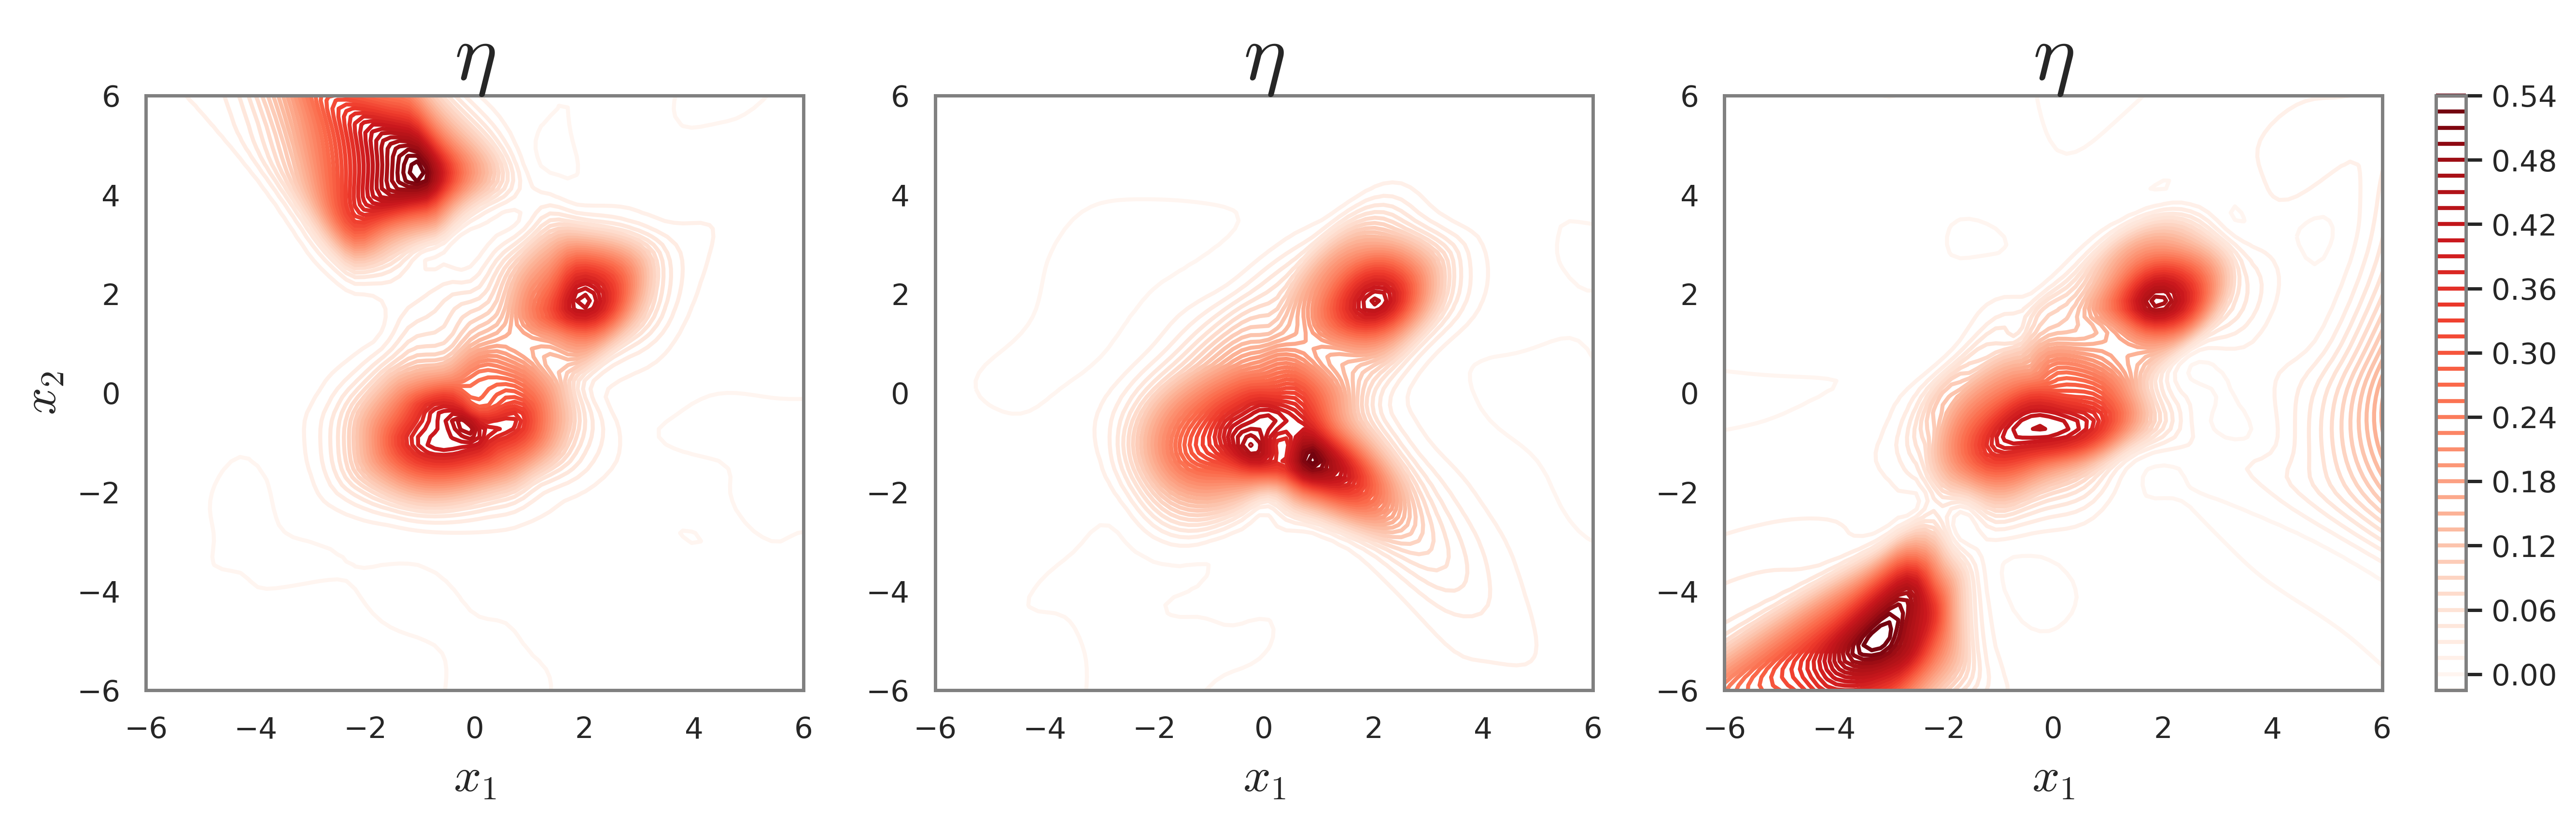

In [34]:
seed_idx = [2,3,4]
seed_idx = [5,12,9]
fig1, ax1 = plt.subplots(1,3,figsize=(18,4), dpi=400) 
vmin = 0#min(torch.min(U1_GRID).item(), np.min(mse_eval_res.u1_grid).item())
vmax = max(torch.max(eta_eval_res_list[5].y_grid).item(), torch.max(eta_eval_res_list[12].y_grid).item(), torch.max(eta_eval_res_list[9].y_grid).item())
# Create contour plots with same levels and color scale
contour_truth = ax1[0].contour(X1,X2,eta_eval_res_list[5].y_grid.cpu().numpy(), levels=36, cmap='Reds', vmin=vmin, vmax=vmax)
ax1[0].set_title(r"$\eta$", fontsize=30)
ax1[0].set_xlabel(r"$x_1$", fontsize=18)
ax1[0].set_ylabel(r"$x_2$", fontsize=18)
ax1[0].set_xlim(-6,6)
ax1[0].set_ylim(-6,6)
contour2 = ax1[1].contour(X1,X2,eta_eval_res_list[12].y_grid.cpu().numpy(), levels=36, cmap='Reds', vmin=vmin, vmax=vmax)
ax1[1].set_title(r"$\eta$", fontsize=30)
ax1[1].set_xlabel(r"$x_1$", fontsize=18)
ax1[1].set_xlim(-6,6)
ax1[1].set_ylim(-6,6)
contour3 = ax1[2].contour(X1,X2,eta_eval_res_list[9].y_grid.cpu().numpy(), levels=36, cmap='Reds', vmin=vmin, vmax=vmax)
ax1[2].set_title(r"$\eta$", fontsize=30)
ax1[2].set_xlabel(r"$x_1$", fontsize=18)
ax1[2].set_xlim(-6,6)
ax1[2].set_ylim(-6,6)
# Add a colorbar that applies to all plots
fig1.colorbar(contour_truth, ax=ax1, shrink=1, pad=0.02)

In [22]:
# Robustness with respect to lambda
"""
Multiple runs of eta-learning
"""
# set seed
from models import *
# seed += 1
eta_lamb_res_list = []
eta_lamb_eval_res_list = []
seed = 25
# set device
_device = device("all")

# quantile loss
quantiles = quantiles
pretrain_epochs = 1000
epochs = 3000
batch_size = n_train
lambda_list = [1e-4, 1e-3, 1e-2, 0.1, 1, 10]
omega = 100

# network parameters
n_neurons = 256
dimensions = [
    n_neurons,n_neurons,n_neurons
]
activation = 'psilu'
indim = 2
outdim = 1
init = 'xavier normal'
loss_fun = nn.MSELoss
optim = torch.optim.Adam

for _lamb in lambda_list:
    global_seed(seed)
    print('seed : ', seed)

    # pretraining
    etann_pretrain = FCNN(dimensions, activation, indim, outdim, init, False).to(_device)
    etann_pretrain = nn.DataParallel(etann_pretrain)
    n_grid = 50
    grid_step = 100 // n_grid
    gaussian_field, center = generate_2d_gaussian(seed=seed, sigma=0.3)
    pretrain_res = grf_pretrain(gaussian_field, etann_pretrain, pretrain_epochs, n_grid=n_grid, grid_step=grid_step, device=_device)

    # continual training
    etann = pretrain_res.model
    eta_res = train_eta_xy(etann, x_train, y_train, X, Y, quantiles,
                            optim, epochs, batch_size, _device, _lamb, omega)
    eta_eval_res = eval_result(eta_res, GRIDS, X, best_model=True)

    eta_lamb_res_list.append(eta_res)
    eta_lamb_eval_res_list.append(eta_eval_res)

    # fig, ax = plt.subplots(1,2,figsize=(12,4))
    # ax[0].contour(X1.numpy(), X2.numpy(), eta_eval_res.y_grid.cpu().numpy(), levels=36, cmap='Reds')
    # ax[0].set_xlim(-6,6)
    # ax[0].set_ylim(-6,6)
    # ax[0].set_xlabel(r'$x_1$')
    # ax[0].set_ylabel(r'$x_2$')

    # y_eta, py_eta, y_eta_pdf = get_data_pdf(eta_eval_res.y_samples, Y, None)
    # ax[1].plot(y_true, py_true, linewidth=2, label='Truth')
    # ax[1].plot(y_mse, py_mse, '-.', linewidth=2, label='MSE')
    # ax[1].plot(y_eta, py_eta, '--', linewidth=2, label=r'$\eta$')
    # ax[1].set_yscale('log')
    # ax[1].set_xlabel(r'$y$')
    # ax[1].set_ylabel(r'$\log p(y)$')
    # ax[1].set_ylim(1e-2, 50)
    # ax[1].legend(prop={'size': 16})

    # fig.tight_layout()
    # plt.show()
        # plt.close()


seed :  25


100%|██████████| 3000/3000 [01:49<00:00, 27.37it/s]


seed :  25


100%|██████████| 3000/3000 [01:52<00:00, 26.76it/s]


seed :  25


...

100%|██████████| 3000/3000 [01:51<00:00, 26.82it/s]


seed :  25


100%|██████████| 3000/3000 [01:52<00:00, 26.65it/s]


seed :  25


100%|██████████| 3000/3000 [01:52<00:00, 26.65it/s]


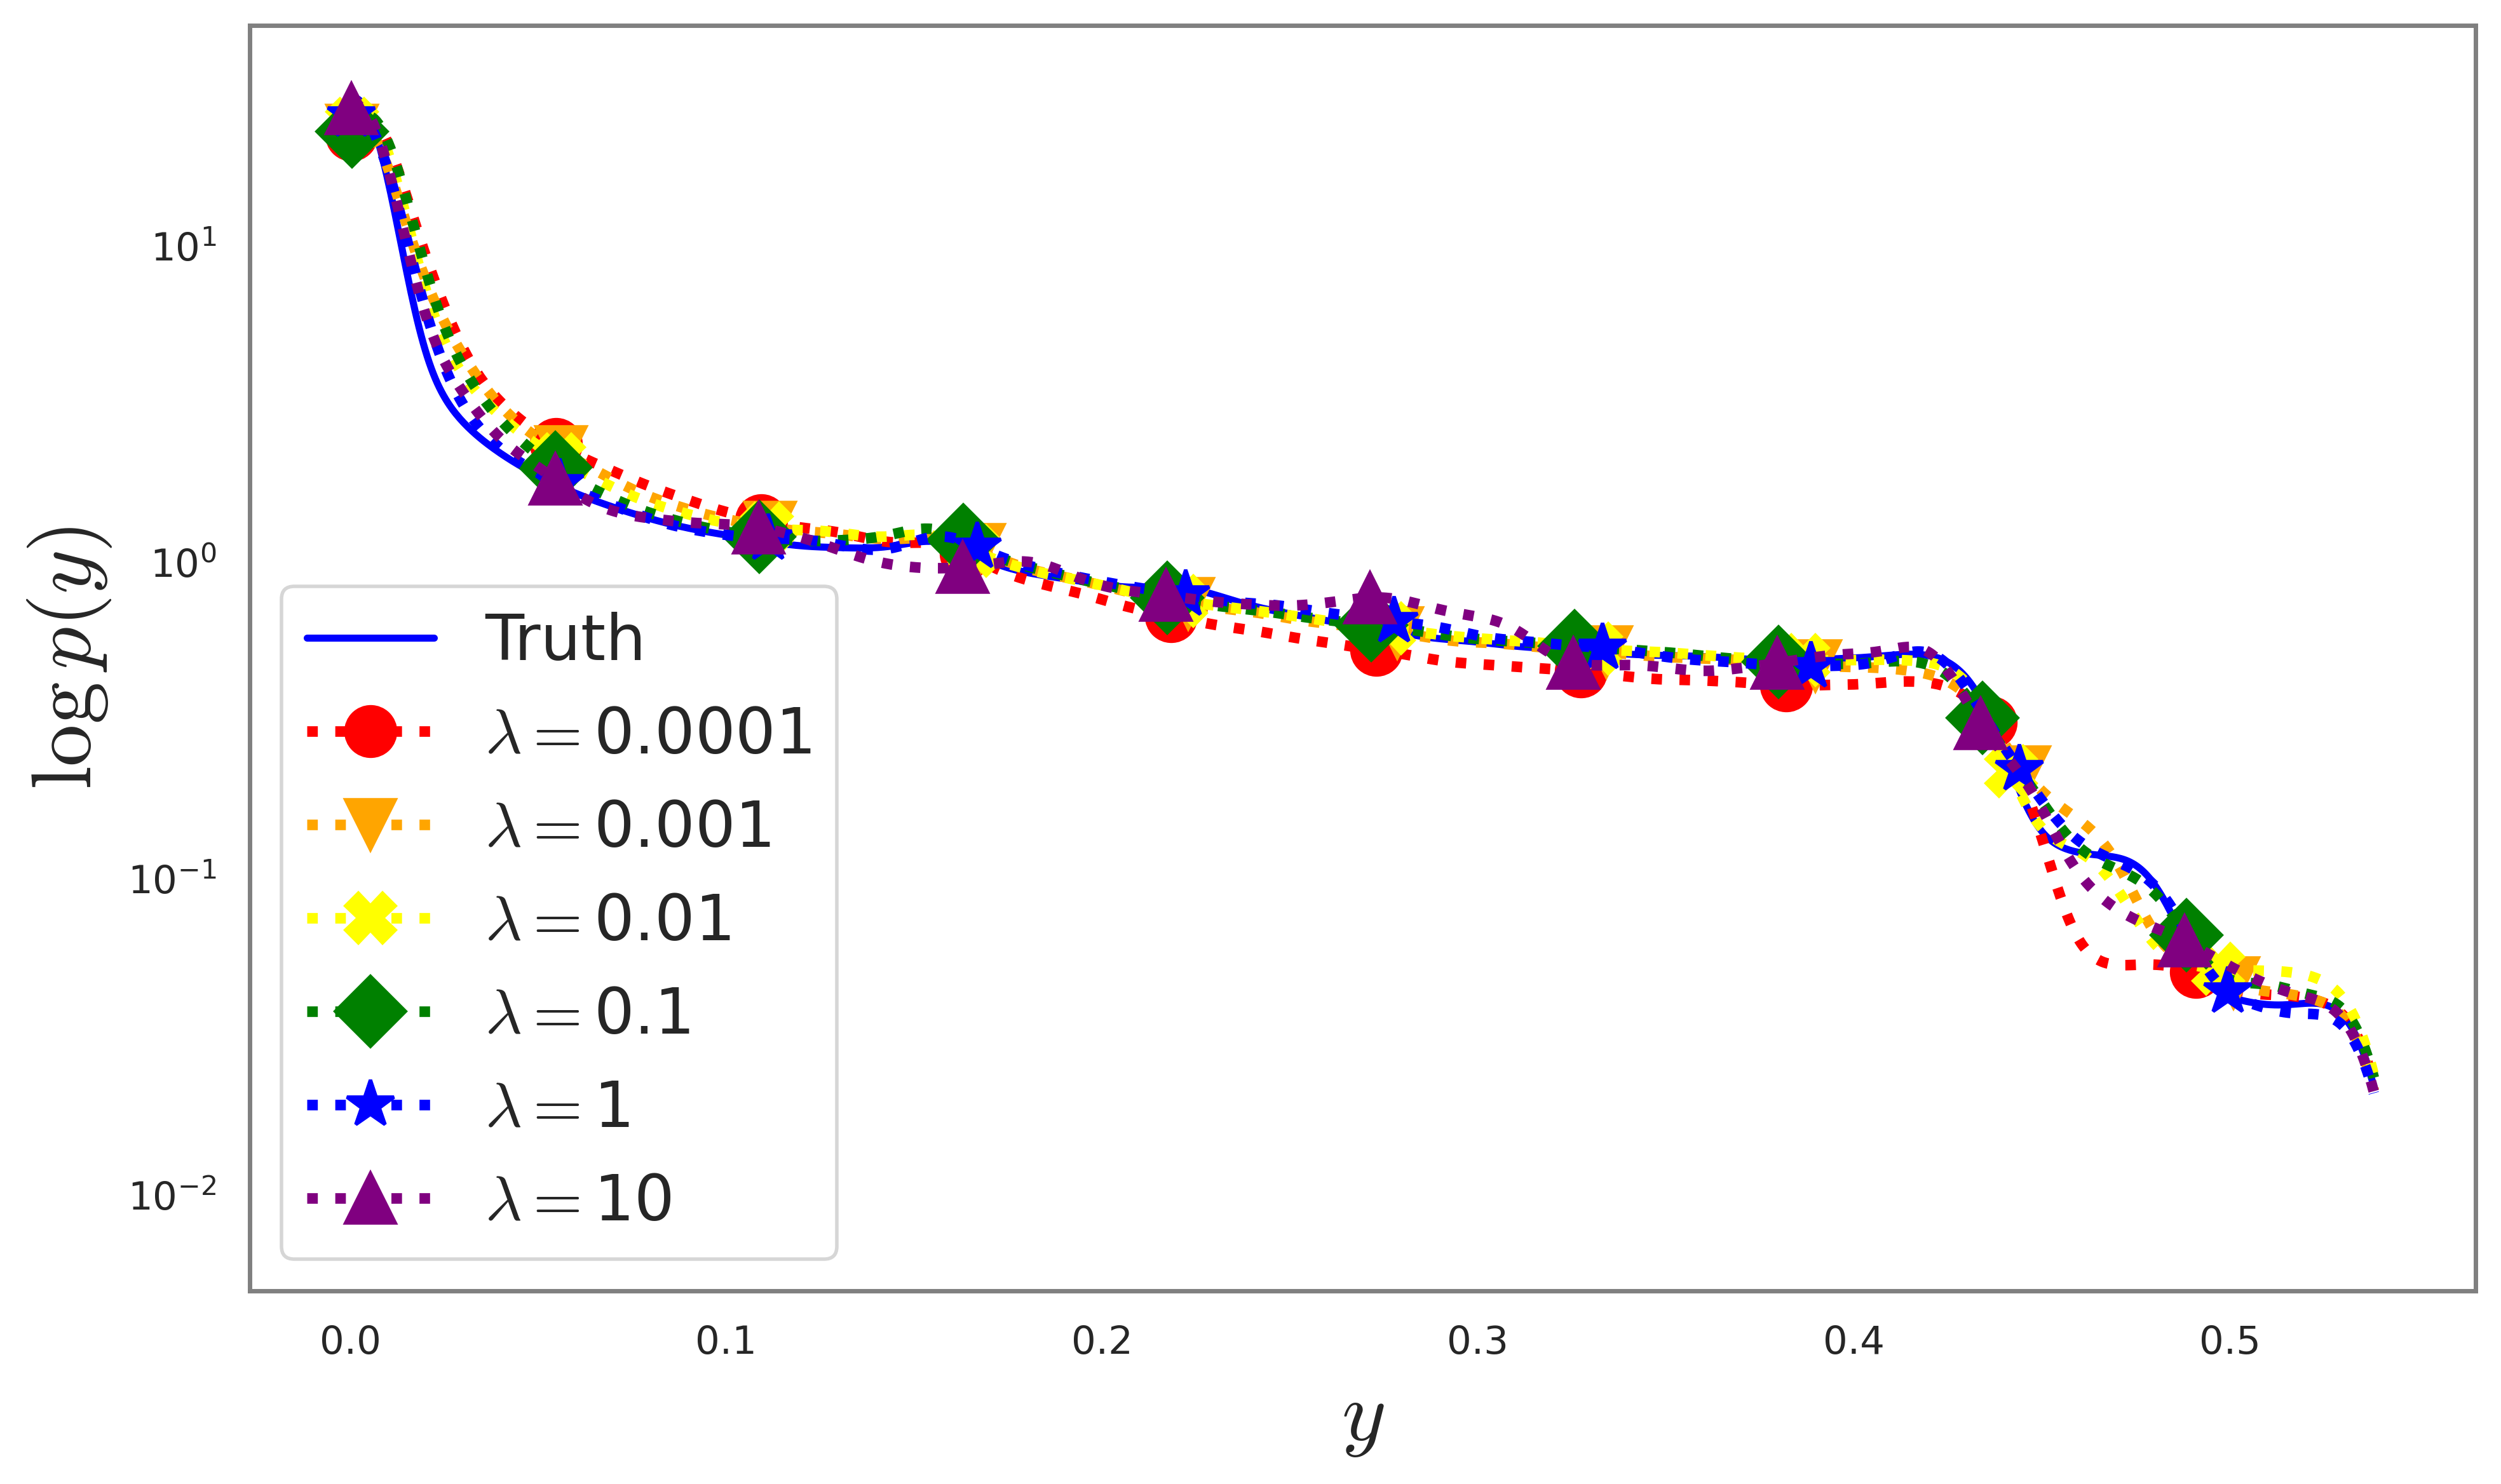

In [26]:
fig = plt.figure(figsize=(10,6), dpi=400)
plt.plot(y_true, py_true, label=r"Truth", color='blue', linestyle='-', linewidth=2)

y_eta_lamb = []
py_eta_lamb = []
for eta_eval_res in eta_lamb_eval_res_list:
    y_eta, py_eta, y_eta_pdf = get_data_pdf(eta_eval_res.y_samples, Y, None)
    y_eta_lamb.append(y_eta)
    py_eta_lamb.append(py_eta)

color_list = ['red', 'orange', 'yellow', 'green', 'blue', 'purple']
marker_list = ['o', 'v', 'X', 'D', '*', '^']
for i, lamb in enumerate(lambda_list):
    plt.plot(y_eta_lamb[i], py_eta_lamb[i], label=r"$\lambda = $" + f"{lamb}", color=color_list[i], linestyle=':', 
            marker=marker_list[i], markersize=14, markevery=100, linewidth=3)
plt.xlabel(r"$y$", fontsize=24)
plt.ylabel(r"$\log{p(y)}$", fontsize=24)
plt.yscale('log')
plt.ylim(5e-3, 50)
plt.legend(prop={'size': 18})
plt.tight_layout()
plt.show()

# Revision experiment: spatial uncertainty across η-estimator realizations

The purpose of this revision diagnostic is not to prove exact recovery of the unobserved extreme location. The purpose is to quantify residual spatial uncertainty under scalar observable calibration. For each available η-estimator realization, evaluated on the existing contour grid $\mathcal G_E=\mathcal G$, we compute
$$
\widehat z_k=\arg\max_{z\in\mathcal G_E}y_\eta^{(k)}(z),\qquad
\widehat a_k=\max_{z\in\mathcal G_E}y_\eta^{(k)}(z),
$$
with true grid-level counterparts
$$
z_\star=\arg\max_{z\in\mathcal G_E}y(z),\qquad a_\star=\max_{z\in\mathcal G_E}y(z).
$$
The reported location and amplitude summaries are
$$
\bar z=\frac1K\sum_{k=1}^K\widehat z_k,
\qquad
V_{\rm loc}=\frac1K\sum_{k=1}^K\|\widehat z_k-\bar z\|_2^2,
$$
$$
E_{\rm loc}=\frac1K\sum_{k=1}^K\|\widehat z_k-z_\star\|_2,
\qquad
E_{\rm amp}=\frac1K\sum_{k=1}^K\frac{|\widehat a_k-a_\star|}{|a_\star|}.
$$
The tail distributional discrepancy uses the same notebook quantile grid whenever possible:
$$
W_{1,Q}\approx \frac1{|Q|}\sum_{q\in Q}\left|Q_{(y_\eta^{(k)})_\#\mu}(q)-Q_{y_\#\mu}(q)\right|.
$$


The following code collects available η realizations, optionally trains missing seeds if the flag is enabled, computes the spatial-uncertainty diagnostics, and displays the table in the notebook. The default keeps the run non-invasive: if fewer than $K=20$ realizations are already present, it reports the available $K$ and leaves the 20-realization rerun parameterized for later execution.


In [14]:
from IPython.display import display
import pandas as pd
from models import FCNN
from train_utils import train_eta_xy, grf_pretrain, generate_2d_gaussian
from test_utils import eval_result
from revision_utils import tail_w1_quantile, to_numpy

REVISION_K_TARGET = 20
RUN_MISSING_ETA_REALIZATIONS = True
REVISION_SEED_POOL = [22, 25, 27, 28, 29, 32, 33, 38, 39, 40,
                      41, 43, 51, 54, 57, 58, 63, 64, 67, 83]

if 'eta_res_list' not in globals():
    eta_res_list = []
if 'eta_eval_res_list' not in globals():
    eta_eval_res_list = []
if 'seed_list' not in globals():
    seed_list = []

available_eta_eval_res = [res for res in eta_eval_res_list if hasattr(res, 'y_grid')]
seeds_already_recorded = list(seed_list[:len(available_eta_eval_res)])
missing_seeds = [s for s in REVISION_SEED_POOL if s not in seeds_already_recorded][:max(0, REVISION_K_TARGET - len(available_eta_eval_res))]

if missing_seeds and RUN_MISSING_ETA_REALIZATIONS:
    _device = device("all")
    pretrain_epochs = globals().get('pretrain_epochs', 1000)
    epochs = globals().get('epochs', 3000)
    batch_size = globals().get('batch_size', n_train)
    _lamb = globals().get('_lamb', 1.0)
    omega = globals().get('omega', 100)
    n_neurons = globals().get('n_neurons', 256)
    dimensions = globals().get('dimensions', [n_neurons, n_neurons, n_neurons])
    activation = globals().get('activation', 'psilu')
    indim = globals().get('indim', 2)
    outdim = globals().get('outdim', 1)
    init = globals().get('init', 'xavier normal')
    optim = globals().get('optim', torch.optim.Adam)
    for revision_seed in missing_seeds:
        global_seed(revision_seed)
        print("training revision seed:", revision_seed)
        etann_pretrain = FCNN(dimensions, activation, indim, outdim, init, False).to(_device)
        etann_pretrain = nn.DataParallel(etann_pretrain)
        gaussian_field, _ = generate_2d_gaussian(seed=revision_seed, sigma=0.3)
        pretrain_res = grf_pretrain(gaussian_field, etann_pretrain, pretrain_epochs,
                                    n_grid=50, grid_step=2, device=_device)
        eta_res = train_eta_xy(pretrain_res.model, x_train, y_train, X, Y, quantiles,
                               optim, epochs, batch_size, _device, _lamb, omega)
        eta_eval_res = eval_result(eta_res, GRIDS, X, best_model=True)
        eta_res_list.append(eta_res)
        eta_eval_res_list.append(eta_eval_res)
        available_eta_eval_res.append(eta_eval_res)
        seeds_already_recorded.append(revision_seed)
        seed_list.append(revision_seed)
elif missing_seeds:
    print(f"Using {len(available_eta_eval_res)} available η realization(s). Set RUN_MISSING_ETA_REALIZATIONS=True to extend to K={REVISION_K_TARGET}.")
else:
    print(f"Using {len(available_eta_eval_res)} available η realization(s); target K={REVISION_K_TARGET} is already met or no seeds remain.")

available_eta_eval_res = available_eta_eval_res[:REVISION_K_TARGET]
seeds_used = seeds_already_recorded[:len(available_eta_eval_res)]
K_revision = len(available_eta_eval_res)
if K_revision == 0:
    raise RuntimeError("No η realizations are available for the revision diagnostic.")

grid_points = to_numpy(GRIDS)
X1_np = to_numpy(X1)
X2_np = to_numpy(X2)
true_grid = to_numpy(Y_GRID).reshape(-1)
true_argmax = int(np.argmax(true_grid))
z_star = grid_points[true_argmax]
a_star = float(true_grid[true_argmax])

z_hats = []
a_hats = []
tail_w1_values = []
eta_grid_stack = []
for eta_eval_res in available_eta_eval_res:
    eta_grid = to_numpy(eta_eval_res.y_grid).reshape(-1)
    eta_grid_stack.append(eta_grid.reshape(X1_np.shape))
    eta_argmax = int(np.argmax(eta_grid))
    z_hats.append(grid_points[eta_argmax])
    a_hats.append(float(eta_grid[eta_argmax]))
    tail_w1_values.append(tail_w1_quantile(eta_eval_res.y_samples, Y, quantiles))

z_hats = np.asarray(z_hats)
a_hats = np.asarray(a_hats)
z_bar = z_hats.mean(axis=0)
V_loc = float(np.mean(np.sum((z_hats - z_bar) ** 2, axis=1)))
E_loc = float(np.mean(np.linalg.norm(z_hats - z_star, axis=1)))
E_amp = float(np.mean(np.abs(a_hats - a_star) / (abs(a_star) + 1e-12)))
revision_extreme_threshold = float(np.quantile(to_numpy(Y).reshape(-1), 0.99))

revision_spatial_uncertainty_df_1d = pd.DataFrame([{
    "K": K_revision,
    "target_K": REVISION_K_TARGET,
    "seeds_used": seeds_used,
    "threshold_t": revision_extreme_threshold,
    "z_star_x1": z_star[0],
    "z_star_x2": z_star[1],
    "z_bar_x1": z_bar[0],
    "z_bar_x2": z_bar[1],
    "V_loc": V_loc,
    "E_loc": E_loc,
    "a_star": a_star,
    "a_hat_mean": float(a_hats.mean()),
    "a_hat_std": float(a_hats.std(ddof=1)) if K_revision > 1 else 0.0,
    "E_amp": E_amp,
    "tail_W1_Q_mean": float(np.mean(tail_w1_values)),
    "tail_W1_Q_std": float(np.std(tail_w1_values, ddof=1)) if K_revision > 1 else 0.0,
}])

display(revision_spatial_uncertainty_df_1d)


training revision seed: 22


100%|██████████| 3000/3000 [01:59<00:00, 25.09it/s]


training revision seed: 25


100%|██████████| 3000/3000 [02:47<00:00, 17.89it/s]


training revision seed: 27


...

training revision seed: 67


100%|██████████| 3000/3000 [01:59<00:00, 25.04it/s]


training revision seed: 83


100%|██████████| 3000/3000 [01:59<00:00, 25.11it/s]


,K,target_K,seeds_used,threshold_t,z_star_x1,z_star_x2,z_bar_x1,z_bar_x2,V_loc,E_loc,a_star,a_hat_mean,a_hat_std,E_amp,tail_W1_Q_mean,tail_W1_Q_std
0,20,20,"[22, 25, 27, 28, 29, 32, 33, 38, 39, 40, 41, 4...",0.433047,2.020202,-2.020202,-0.113131,-0.460606,15.935353,4.245257,0.537137,0.53594,0.002714,0.003821,0.001698,0.00058


The exceedance-probability map is
$$
\widehat p_\eta(z;t)=\frac1K\sum_{k=1}^K\mathbf 1\{y_\eta^{(k)}(z)>t\}.
$$
Here $t$ is the empirical 0.99 quantile of the true observable over the reference/evaluation samples when no separate toy threshold is defined in the notebook.


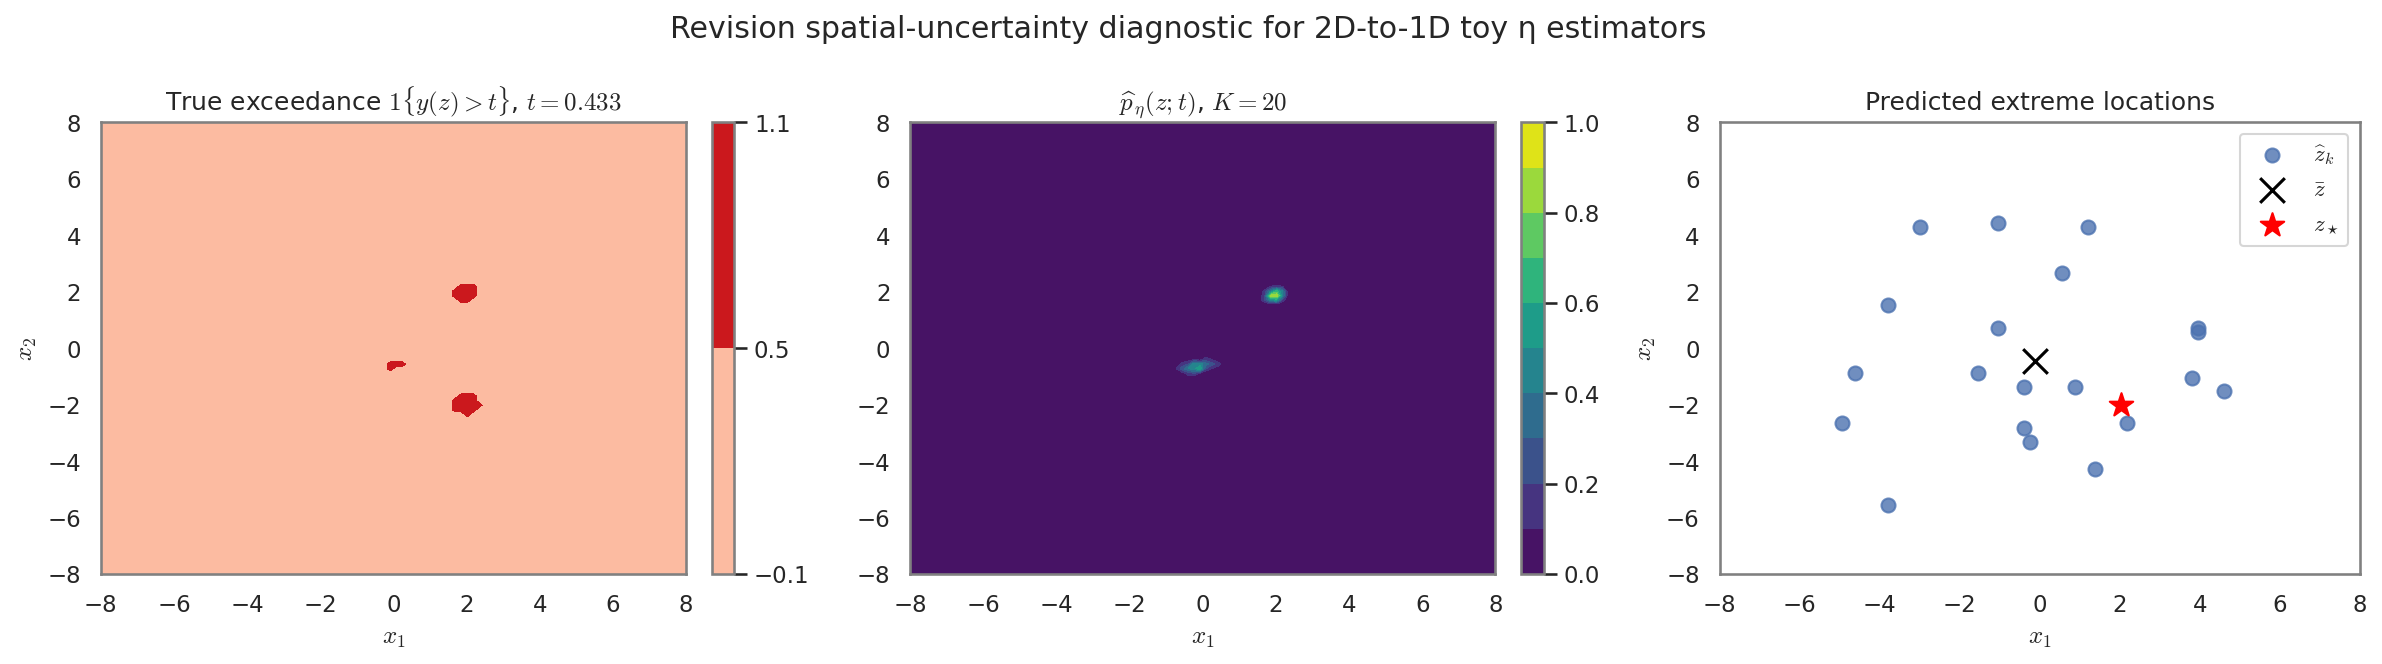

In [15]:
eta_grid_stack = np.stack(eta_grid_stack, axis=0)
true_grid_2d = to_numpy(Y_GRID)
true_exceedance = (true_grid_2d > revision_extreme_threshold).astype(float)
p_eta = (eta_grid_stack > revision_extreme_threshold).mean(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), dpi=150)
truth_img = axes[0].contourf(X1_np, X2_np, true_exceedance, levels=[-0.1, 0.5, 1.1], cmap='Reds')
axes[0].set_title(rf"True exceedance $1\{{y(z)>t\}}$, $t={revision_extreme_threshold:.3f}$")
axes[0].set_xlabel(r"$x_1$")
axes[0].set_ylabel(r"$x_2$")
fig.colorbar(truth_img, ax=axes[0], fraction=0.046, pad=0.04)

prob_img = axes[1].contourf(X1_np, X2_np, p_eta, levels=np.linspace(0, 1, 11), cmap='viridis')
axes[1].set_title(rf"$\widehat p_\eta(z;t)$, $K={K_revision}$")
axes[1].set_xlabel(r"$x_1$")
fig.colorbar(prob_img, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].scatter(z_hats[:, 0], z_hats[:, 1], s=45, label=r"$\widehat z_k$", alpha=0.8)
axes[2].scatter([z_bar[0]], [z_bar[1]], s=140, marker='x', color='black', label=r"$\bar z$")
axes[2].scatter([z_star[0]], [z_star[1]], s=140, marker='*', color='red', label=r"$z_\star$")
axes[2].set_title("Predicted extreme locations")
axes[2].set_xlabel(r"$x_1$")
axes[2].set_ylabel(r"$x_2$")
axes[2].set_xlim(float(np.min(X1_np)), float(np.max(X1_np)))
axes[2].set_ylim(float(np.min(X2_np)), float(np.max(X2_np)))
axes[2].legend()
fig.suptitle("Revision spatial-uncertainty diagnostic for 2D-to-1D toy η estimators")
fig.tight_layout()
plt.show()


# Revision documentation notes

This notebook corresponds to the paper's 2D-to-1D toy scalar-map experiment. The revision section added above displays a spatial-uncertainty table, an exceedance-probability map, and a scatter plot of η-realization extreme locations. No revision tables or figures are saved to disk; they are displayed directly in the notebook. Existing cells, outputs, saved SI figures, and experiment logic were not modified. The existing notebook contains earlier exploratory multi-run and lambda-sweep cells; that redundancy is preserved for backward reproducibility.
